## KDE

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import normal 

In [27]:
sample_1 = normal(loc=20,scale=5,size=300)
sample_2 = normal(loc=40,scale=5,size=700)

sample = np.hstack((sample_1,sample_2))
sample

array([27.42922464, 27.68080642, 28.32167959, 23.57633252, 22.74037476,
       16.54948426, 20.3901588 , 20.45791888,  7.90249346, 21.73239225,
       15.98872026, 19.42604545, 16.71792555, 25.62818707, 18.30642446,
       25.88025891, 13.6938302 , 15.48347276, 28.94525104, 16.33098497,
       24.13811268, 23.72111055, 22.80714716, 15.99794893, 11.866045  ,
       10.1264626 , 18.91771831,  5.66263226, 25.45735973, 16.49332997,
       19.78520364, 25.9012894 , 23.43135067, 17.83417552, 22.84254537,
       21.61753982, 23.65009178, 10.61400747, 16.8566418 , 21.15937356,
       20.38868477, 27.68972798, 18.76491637, 22.92866276, 20.81549766,
       12.0573286 , 27.84625731, 23.29862876, 20.62603399, 16.30629322,
       16.71928956, 26.39745479, 16.36851738, 20.99724933, 24.38265242,
       19.61059693, 21.21080834, 23.39734719,  9.09876347, 16.06711145,
       19.88194898, 20.7270612 , 12.34358027, 28.86317742, 24.78148224,
       18.88065669, 14.80603332, 22.43603301, 17.62535597, 19.56

## plotting histogram

(array([ 1.,  0.,  1.,  3.,  3.,  5.,  5.,  5., 11., 14., 25., 22., 25.,
        19., 28., 22., 24., 18., 16., 11., 13.,  6., 20., 14., 12.,  7.,
        21., 26., 27., 32., 44., 29., 46., 58., 52., 53., 52., 48., 46.,
        40., 28., 24., 15.,  9.,  6.,  3.,  2.,  3.,  4.,  2.]),
 array([ 5.66263226,  6.65108352,  7.63953478,  8.62798604,  9.6164373 ,
        10.60488856, 11.59333982, 12.58179108, 13.57024233, 14.55869359,
        15.54714485, 16.53559611, 17.52404737, 18.51249863, 19.50094989,
        20.48940115, 21.47785241, 22.46630367, 23.45475493, 24.44320619,
        25.43165744, 26.4201087 , 27.40855996, 28.39701122, 29.38546248,
        30.37391374, 31.362365  , 32.35081626, 33.33926752, 34.32771878,
        35.31617004, 36.3046213 , 37.29307255, 38.28152381, 39.26997507,
        40.25842633, 41.24687759, 42.23532885, 43.22378011, 44.21223137,
        45.20068263, 46.18913389, 47.17758515, 48.16603641, 49.15448766,
        50.14293892, 51.13139018, 52.11984144, 53.1082927 ,

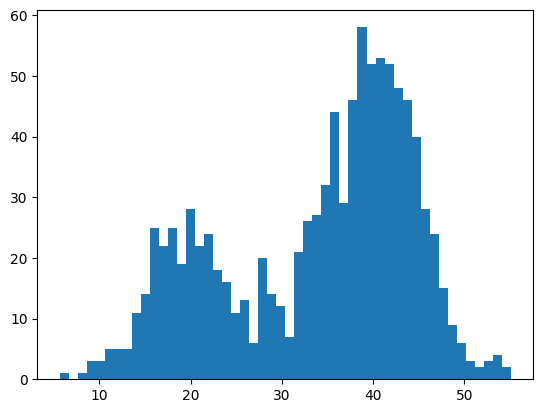

In [28]:
plt.hist(sample,bins=50)

## Preparing KDE 

In [29]:
from sklearn.neighbors import KernelDensity

model = KernelDensity(bandwidth=3,kernel="gaussian")

#Convert data to a 2d array
sample=  sample.reshape((len(sample),1))

model.fit(sample)

KernelDensity(bandwidth=3)

In [30]:
values = np.linspace(sample.min(),sample.max(),100)
values= values.reshape(len(values),1)


In [31]:
probablity= model.score_samples(values)
probablity=np.exp(probablity)

## Graph Plot

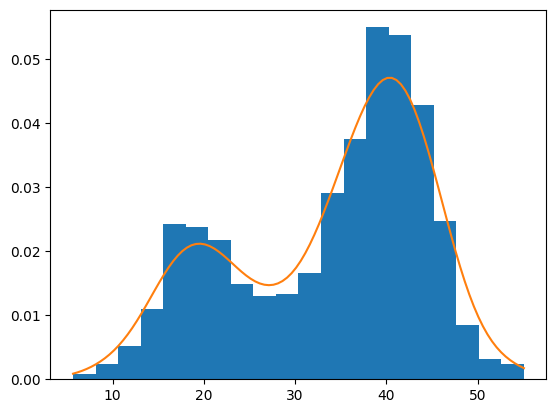

In [32]:
plt.hist(sample,bins=20,density=True)
plt.plot(values[:],probablity)
plt.show()

In [33]:
import pandas as pd

In [34]:
titanic = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

In [35]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<Axes: xlabel='Age', ylabel='Density'>

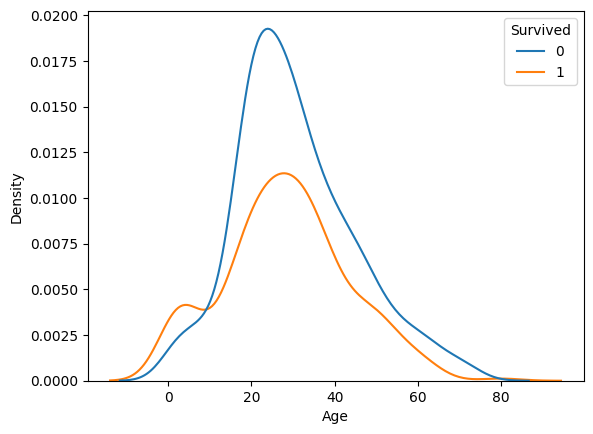

In [36]:
import seaborn as sns

sns.kdeplot(data=titanic,x='Age' ,hue='Survived')


### The above graph represents that the if you age is around 8 so your chances of survival are much higher than death

## Functional Transformation

In [37]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer


train = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv",usecols=['Age','Survived','Fare'])
train.head()
# train['Age'].fillna(train['Age'].mean(),inplace=True)




,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [38]:
train.isnull().sum()
# train['Age'] = train['Age'].fillna(train['Age'].mean())


Survived      0
Age         177
Fare          0
dtype: int64

In [39]:
x = train.iloc[:,1:3]
y = train.iloc[:,0]

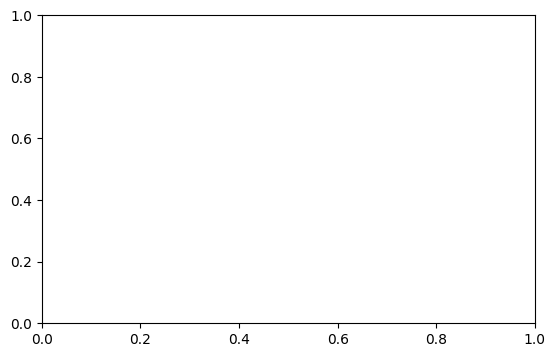

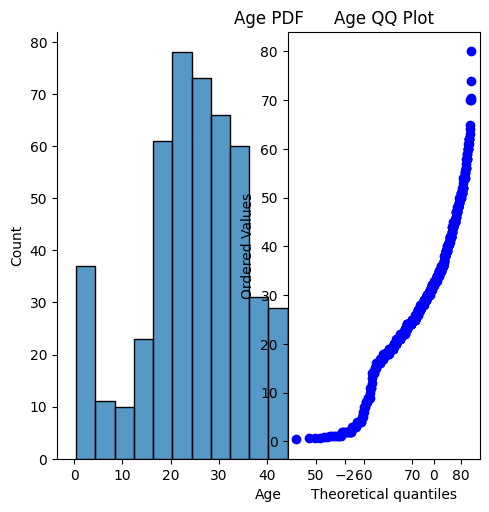

In [40]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
 
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.displot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(122)
stats.probplot(X_train['Age'],dist="norm",plot=plt)
plt.title("Age QQ Plot")
plt.show()